In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load the CSV files
gist_csv = '/mnthdd/cpanourg/2-hdvc/results/relerr/gist_PQ_adc_vs_exact_eval.csv'
deep_csv = '/mnthdd/cpanourg/2-hdvc/results/relerr/deep_PQ_adc_vs_exact_eval.csv'

# Load data
df_gist = pd.read_csv(gist_csv)
df_deep = pd.read_csv(deep_csv)

# Add dataset column if not present
df_gist['dataset'] = 'gist'
df_deep['dataset'] = 'deep'

# Combine datasets
df_all = pd.concat([df_gist, df_deep], ignore_index=True)

print(f"Gist dataset shape: {df_gist.shape}")
print(f"Deep dataset shape: {df_deep.shape}")
print(f"\nGist - bits_per_vector values: {sorted(df_gist['bits_per_vector'].unique())}")
print(f"Deep - bits_per_vector values: {sorted(df_deep['bits_per_vector'].unique())}")

# Filter for train_size == 100000000
df_gist_filtered = df_gist[df_gist['train_size'] == 100000000].copy()
df_deep_filtered = df_deep[df_deep['train_size'] == 100000000].copy()

print(f"\nGist filtered (train_size=100000000): {len(df_gist_filtered)} rows")
print(f"Deep filtered (train_size=100000000): {len(df_deep_filtered)} rows")
print(f"\nGist - bits_per_vector values available: {sorted(df_gist_filtered['bits_per_vector'].unique())}")
print(f"Deep - bits_per_vector values available: {sorted(df_deep_filtered['bits_per_vector'].unique())}")


Gist dataset shape: (29, 18)
Deep dataset shape: (47, 18)

Gist - bits_per_vector values: [4, 6, 8, 10, 12, 14, 16, 24, 32, 40, 48, 56, 64, 80, 96, 112, 128, 160, 192, 224, 256, 512, 2560, 3840]
Deep - bits_per_vector values: [4, 6, 8, 10, 12, 14, 16, 32, 48, 64, 80, 96, 112, 128, 160, 192, 224, 256, 384]

Gist filtered (train_size=100000000): 29 rows
Deep filtered (train_size=100000000): 31 rows

Gist - bits_per_vector values available: [4, 6, 8, 10, 12, 14, 16, 24, 32, 40, 48, 56, 64, 80, 96, 112, 128, 160, 192, 224, 256, 512, 2560, 3840]
Deep - bits_per_vector values available: [4, 6, 8, 10, 12, 14, 16, 32, 48, 64, 80, 96, 112, 128, 160, 192, 224, 256, 384]


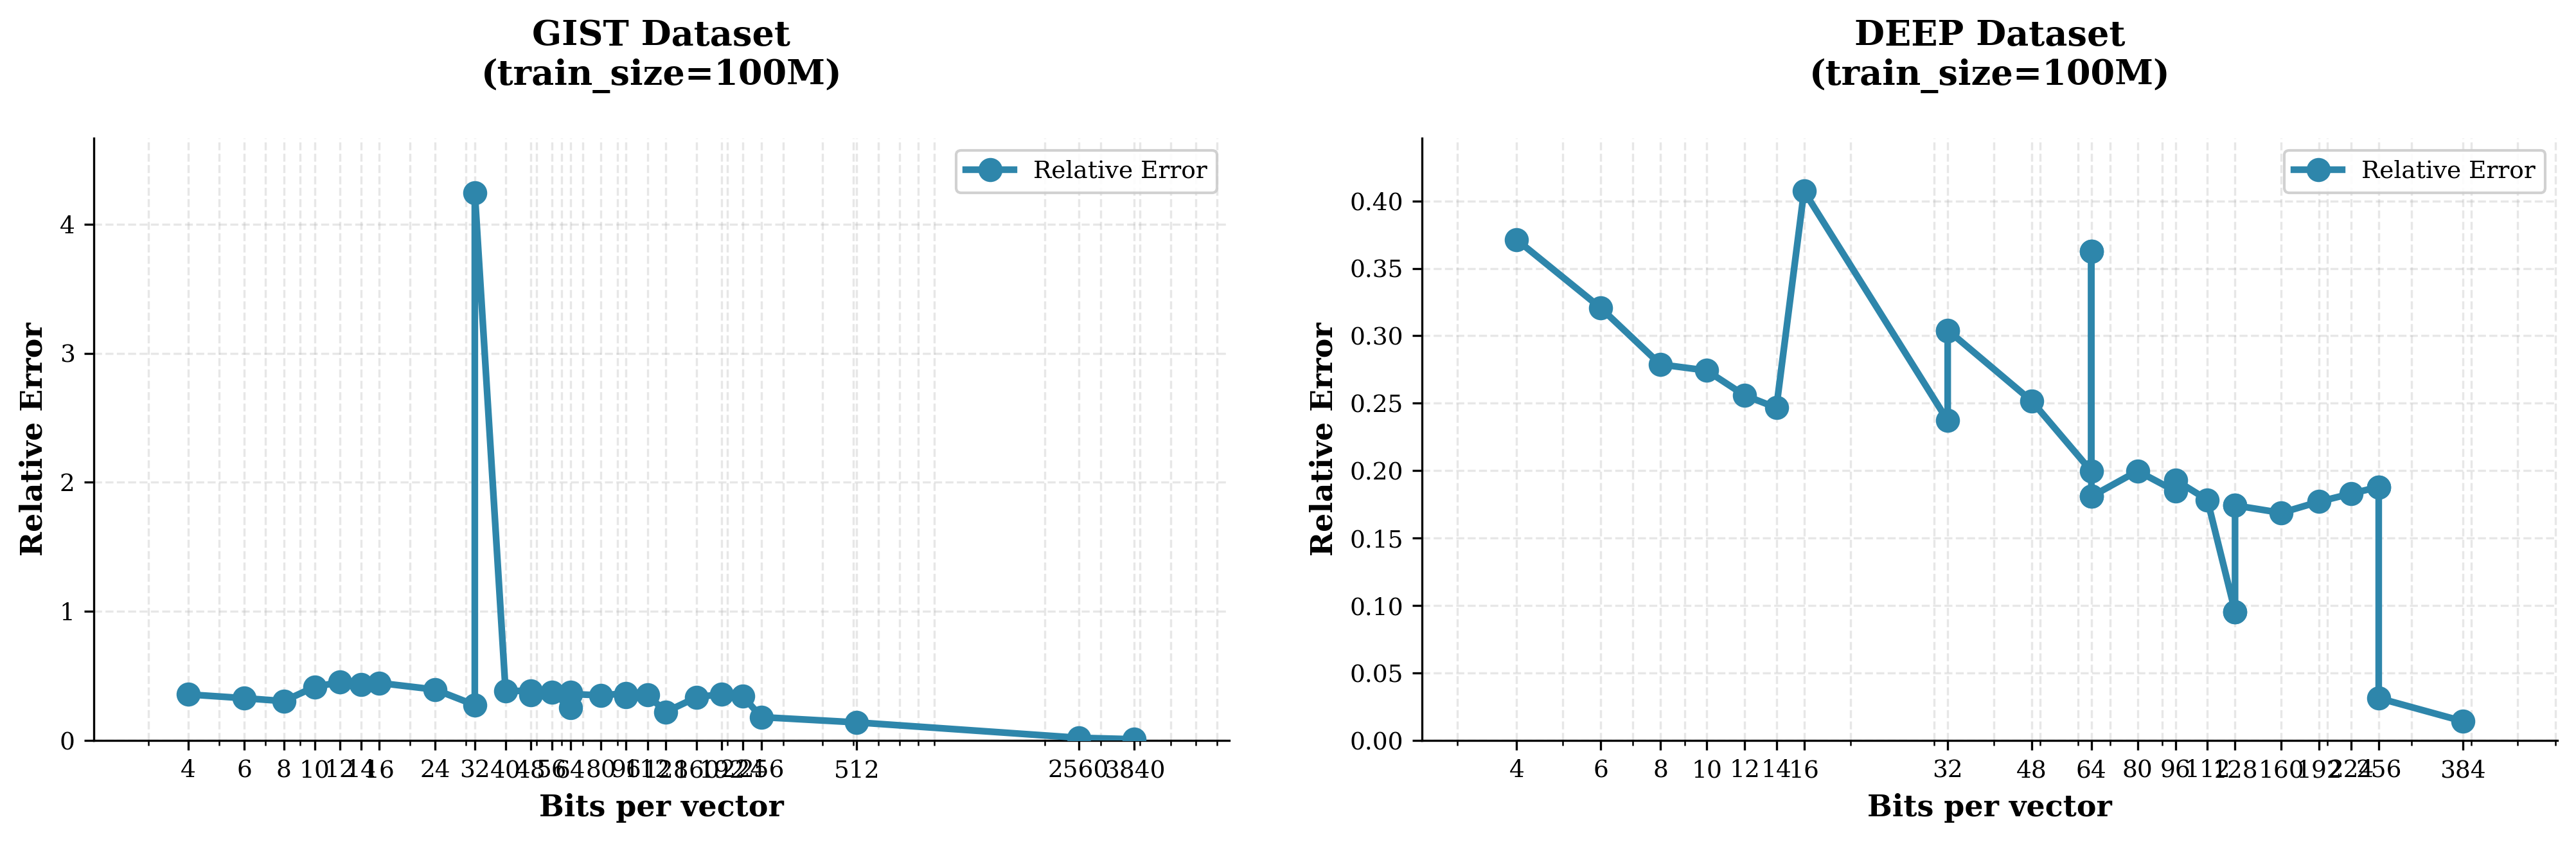


Summary: Impact of bits_per_vector on relative error (train_size=100M)

GIST Dataset:
  bits_per_vector=  4: rel_error_mean=0.3572
  bits_per_vector=  6: rel_error_mean=0.3283
  bits_per_vector=  8: rel_error_mean=0.3054
  bits_per_vector= 10: rel_error_mean=0.4155
  bits_per_vector= 12: rel_error_mean=0.4522
  bits_per_vector= 14: rel_error_mean=0.4359
  bits_per_vector= 16: rel_error_mean=0.4460
  bits_per_vector= 24: rel_error_mean=0.3950
  bits_per_vector= 32: rel_error_mean=0.2751
  bits_per_vector= 32: rel_error_mean=4.2424
  bits_per_vector= 40: rel_error_mean=0.3845
  bits_per_vector= 48: rel_error_mean=0.3843
  bits_per_vector= 48: rel_error_mean=0.3564
  bits_per_vector= 56: rel_error_mean=0.3759
  bits_per_vector= 64: rel_error_mean=0.2561
  bits_per_vector= 64: rel_error_mean=0.3737
  bits_per_vector= 64: rel_error_mean=0.3601
  bits_per_vector= 80: rel_error_mean=0.3507
  bits_per_vector= 96: rel_error_mean=0.3650
  bits_per_vector= 96: rel_error_mean=0.3384
  bits_per_ve

In [2]:
# Set style (paper-quality minimalist)
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "serif",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Create plots for each dataset
datasets = [
    ('gist', df_gist_filtered),
    ('deep', df_deep_filtered)
]

# Increase figure size for better visibility
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5))

# If only one dataset, axes might be a single object
if len(datasets) == 1:
    axes = [axes]

for idx, (dataset_name, df_filtered) in enumerate(datasets):
    ax = axes[idx]
    
    if len(df_filtered) == 0:
        ax.text(0.5, 0.5, f'No data for {dataset_name}\n(train_size=100M)', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size=100M)', fontweight='bold')
        continue
    
    # Sort by bits_per_vector for proper line plotting
    df_sorted = df_filtered.sort_values('bits_per_vector')
    
    # Plot mean relative error (no error bars)
    ax.plot(
        df_sorted['bits_per_vector'], 
        df_sorted['rel_error_mean'],
        marker='o',
        markersize=8,
        linewidth=2.5,
        color='#2E86AB',
        label='Relative Error',
        zorder=3
    )
    
    # Use log scale for x-axis since values may span a large range
    ax.set_xscale('log')
    
    # Styling
    ax.set_xlabel('Bits per vector', fontsize=11, fontweight='bold')
    ax.set_ylabel('Relative Error', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size=100M)', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, which='both')
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    
    # Set x-axis to show only the actual bits_per_vector values
    unique_bpv = sorted(df_sorted['bits_per_vector'].unique())
    ax.set_xticks(unique_bpv)
    ax.set_xticklabels([str(int(x)) for x in unique_bpv], rotation=0)
    
    # Set reasonable y-axis limits with some padding
    y_min = df_sorted['rel_error_mean'].min()
    y_max = df_sorted['rel_error_mean'].max()
    y_range = y_max - y_min
    ax.set_ylim(max(0, y_min - y_range * 0.05), y_max + y_range * 0.1)
    
    # Better margins
    ax.margins(x=0.1, y=0.05)

plt.tight_layout(pad=3.0)
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("Summary: Impact of bits_per_vector on relative error (train_size=100M)")
print("="*70)
for dataset_name, df_filtered in datasets:
    if len(df_filtered) == 0:
        continue
    df_sorted = df_filtered.sort_values('bits_per_vector')
    print(f"\n{dataset_name.upper()} Dataset:")
    for _, row in df_sorted.iterrows():
        print(f"  bits_per_vector={row['bits_per_vector']:3d}: rel_error_mean={row['rel_error_mean']:.4f}")
